# Hancock Dataset — Multi-Task Tumor Classification

Trains a single EfficientNetB0 model with **three output heads** on H&E slide images from `hancock_images/`.

Each `patient_<id>/` folder contains up to two JPEGs:
- `PrimaryTumor_HE_<xxx>.jpg`
- `LymphNode_HE_<xxx>.jpg`

| Head | Task | Classes |
|------|------|---------|
| 1 | `primary_tumor_site` | Larynx / Oral_Cavity / Oropharynx / Hypopharynx / CUP |
| 2 | `grading` | G1 / G2 / G3 |
| 3 | `hpv_association_p16` | negative / not_tested / positive |

Only patients in `pathological_data_filtered.csv` whose folder exists on disk are used.

> **Framework:** TensorFlow 2.20 + `tf_keras` (legacy Keras 2 API) — avoids Keras 3 weight-loading conflicts.

In [12]:
# tf_keras is the standalone legacy Keras 2 package maintained by the TF team.
# It works with TF 2.16+ / 2.20+ without any Keras 3 interference.
# After installing, RESTART the kernel before running the next cell.
%pip install tf_keras pillow tqdm scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [1]:
import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

# ── Use tf_keras (legacy Keras 2) — NOT standalone keras 3 ────────────────
# This gives us the stable tf.keras API on TF 2.16+ without Keras 3 conflicts.
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'   # must be set before importing tf_keras
import tf_keras as keras
from tf_keras import layers, models, Input
from tf_keras.applications import EfficientNetB0
from tf_keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f'TensorFlow : {tf.__version__}')
print(f'tf_keras   : {keras.__version__}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow : 2.21.0
tf_keras   : 2.21.0


In [2]:
CSV_PATH   = 'pathological_data.csv'
IMAGES_DIR = 'hancock_images'       # root: patient_102/, patient_104/, …
MODEL_DIR  = 'models_hancock'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20

# Which slide types to include. Set either to False to exclude.
USE_PRIMARY_TUMOR = True
USE_LYMPH_NODE    = True

In [3]:
df = pd.read_csv(CSV_PATH)


# ── Drop rows where any label column is empty ─────────────────────────────
LABEL_COLS = ['primary_tumor_site', 'grading', 'hpv_association_p16']
before = len(df)
df = df.dropna(subset=LABEL_COLS).copy()
print(f'Dropped {before - len(df)} rows with missing labels; {len(df)} rows remain.')

# ── Fix known data-entry artefact ──────────────────────────────────────────
# Some HPV-positive Oropharynx rows have 'hpv_association_p16' in the grading
# column (the column name itself), meaning grading was not recorded.
# Treat those as NaN so they are excluded from the grading head only.
df['grading'] = df['grading'].replace('hpv_association_p16', np.nan)

# ── Keep only patients whose image folder exists on disk ───────────────────
def patient_folder(pid):
    return os.path.join(IMAGES_DIR, f'patient_{pid}')

df['folder_exists'] = df['patient_id'].apply(
    lambda pid: os.path.isdir(patient_folder(pid))
)

missing = df[~df['folder_exists']]['patient_id'].tolist()
if missing:
    print(f'Patients in CSV but missing on disk ({len(missing)}): {missing[:20]}...')

df = df[df['folder_exists']].copy()
print(f'Patients with images: {len(df)}')


# ── Remove singleton site classes (only 1 patient — unlearnable) ──────────
site_counts = df['primary_tumor_site'].value_counts()
singleton_sites = site_counts[site_counts < 3].index.tolist()
if singleton_sites:
    print(f'Dropping singleton site classes (too few to learn): {singleton_sites}')
    df = df[~df['primary_tumor_site'].isin(singleton_sites)].copy()

# ── Encode labels ──────────────────────────────────────────────────────────
SITE_CLASSES  = sorted(df['primary_tumor_site'].dropna().unique())
GRADE_CLASSES = ['G1', 'G2', 'G3']
HPV_CLASSES   = ['negative', 'not_tested', 'positive']

SITE_TO_INT  = {v: i for i, v in enumerate(SITE_CLASSES)}
GRADE_TO_INT = {v: i for i, v in enumerate(GRADE_CLASSES)}
HPV_TO_INT   = {v: i for i, v in enumerate(HPV_CLASSES)}

df['site_label']  = df['primary_tumor_site'].map(SITE_TO_INT)
df['grade_label'] = df['grading'].map(GRADE_TO_INT)          # NaN where missing
df['hpv_label']   = df['hpv_association_p16'].map(HPV_TO_INT)

print('\nprimary_tumor_site:', df['primary_tumor_site'].value_counts().to_dict())
print('grading:           ', df['grading'].value_counts().to_dict())
print('hpv_association:   ', df['hpv_association_p16'].value_counts().to_dict())

Dropped 0 rows with missing labels; 763 rows remain.
Patients in CSV but missing on disk (109): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]...
Patients with images: 654
Dropping singleton site classes (too few to learn): ['CUP']

primary_tumor_site: {'Oropharynx': 285, 'Larynx': 178, 'Oral_Cavity': 120, 'Hypopharynx': 70}
grading:            {'G3': 315, 'G2': 202, 'G1': 14}
hpv_association:    {'not_tested': 369, 'negative': 162, 'positive': 122}


In [4]:
# Scan patient folders and record which images are available
image_records = []
missing_both  = []

for _, row in df.iterrows():
    pid    = row['patient_id']
    folder = os.path.join(IMAGES_DIR, f'patient_{pid}')

    if not os.path.isdir(folder):
        continue

    files = os.listdir(folder)

    # Match by prefix (case-insensitive) — filename suffix may vary
    primary = [f for f in files if f.lower().startswith('primarytumor_he')]
    lymph   = [f for f in files if f.lower().startswith('lymphnode_he')]

    slides_to_add = []
    if USE_PRIMARY_TUMOR and primary:
        slides_to_add.append(('primary_tumor', os.path.join(folder, primary[0])))
    if USE_LYMPH_NODE and lymph:
        slides_to_add.append(('lymph_node', os.path.join(folder, lymph[0])))

    if not slides_to_add:
        missing_both.append(pid)
        continue

    for slide_type, img_path in slides_to_add:
        image_records.append({
            'img_path'   : img_path,
            'slide_type' : slide_type,
            'patient_id' : pid,
            'site_label' : int(row['site_label']),
            'grade_label': int(row['grade_label']) if pd.notna(row['grade_label']) else -1,
            'hpv_label'  : int(row['hpv_label'])   if pd.notna(row['hpv_label'])  else -1,
        })

if missing_both:
    print(f'Patients with no matching images ({len(missing_both)}): {missing_both[:20]}')

img_df = pd.DataFrame(image_records)
print(f'Total images  : {len(img_df)}')
print(f'Unique patients: {img_df["patient_id"].nunique()}')
print()
print('Slide type breakdown:')
print(img_df['slide_type'].value_counts().to_string())
print()
print('Label distributions:')
print('  site :', img_df['site_label'].value_counts().to_dict())
print('  grade:', img_df['grade_label'].value_counts().to_dict())
print('  hpv  :', img_df['hpv_label'].value_counts().to_dict())

Total images  : 931
Unique patients: 653

Slide type breakdown:
slide_type
primary_tumor    613
lymph_node       318

Label distributions:
  site : {3: 447, 1: 217, 2: 156, 0: 111}
  grade: {2: 458, 1: 255, -1: 203, 0: 15}
  hpv  : {1: 485, 0: 243, 2: 203}


In [5]:
# Train / val split at the PATIENT level to prevent data leakage.
# Attempts stratification on site; falls back to random if any class
# has only 1 patient (too few to put in both splits).
from collections import Counter

patient_site = (
    img_df.groupby('patient_id')['site_label']
    .first()
    .reset_index()
)
patient_ids   = patient_site['patient_id'].values
patient_sites = patient_site['site_label'].values

class_counts  = Counter(patient_sites)
singleton_cls = [c for c, n in class_counts.items() if n < 2]

if singleton_cls:
    print(f'WARNING: site classes {singleton_cls} have only 1 patient — '
          'using non-stratified split.')
    stratify_arg = None
else:
    stratify_arg = patient_sites

train_pids, val_pids = train_test_split(
    patient_ids,
    test_size    = 0.2,
    random_state = SEED,
    stratify     = stratify_arg,
)

train_df = img_df[img_df['patient_id'].isin(train_pids)].reset_index(drop=True)
val_df   = img_df[img_df['patient_id'].isin(val_pids)].reset_index(drop=True)

print(f'Train: {len(train_df)} images  ({len(train_pids)} patients)')
print(f'Val  : {len(val_df)} images  ({len(val_pids)} patients)')
print('\nVal site distribution:', val_df['site_label'].value_counts().to_dict())


Train: 744 images  (522 patients)
Val  : 187 images  (131 patients)

Val site distribution: {3: 90, 1: 46, 2: 30, 0: 21}


In [6]:
def load_and_preprocess(path, site, grade, hpv, training=True):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        img = tf.image.random_hue(img, 0.05)
        k   = tf.random.uniform([], 0, 4, dtype=tf.int32)
        img = tf.image.rot90(img, k)
        img = tf.clip_by_value(img, 0.0, 1.0)

    return img, (site, grade, hpv)


def make_dataset(frame, training=True):
    ds = tf.data.Dataset.from_tensor_slices((
        frame['img_path'].tolist(),
        tf.cast(frame['site_label'].tolist(),  tf.int32),
        tf.cast(frame['grade_label'].tolist(), tf.int32),
        tf.cast(frame['hpv_label'].tolist(),   tf.int32),
    ))
    ds = ds.map(
        lambda p, s, g, h: load_and_preprocess(p, s, g, h, training=training),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    if training:
        ds = ds.shuffle(buffer_size=len(frame), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)

for imgs, (s, g, h) in train_ds.take(1):
    print('Batch image shape:', imgs.shape)
    print('Site  labels:', s[:8].numpy())
    print('Grade labels (-1=missing):', g[:8].numpy())
    print('HPV   labels (-1=missing):', h[:8].numpy())


Batch image shape: (32, 224, 224, 3)
Site  labels: [3 3 1 0 3 0 2 3]
Grade labels (-1=missing): [-1 -1  2  2  1  2  1 -1]
HPV   labels (-1=missing): [2 2 1 1 0 1 1 2]


In [7]:
def class_weights_dict(labels_series, n_classes, max_weight=10.0):
    """
    Balanced class weights, capped at max_weight.
    Without a cap, a singleton class (1 patient) produces a weight of ~100+
    which explodes the loss scale and prevents any learning.
    Ignores -1 (missing label sentinel).
    """
    valid = labels_series[labels_series >= 0].values
    if len(valid) == 0:
        return {i: 1.0 for i in range(n_classes)}

    present_classes = np.unique(valid)
    weights = compute_class_weight('balanced', classes=present_classes, y=valid)
    weight_map = dict(zip(present_classes, weights))

    result = {i: min(weight_map.get(i, 1.0), max_weight) for i in range(n_classes)}
    return result


site_cw  = class_weights_dict(train_df['site_label'],  len(SITE_CLASSES))
grade_cw = class_weights_dict(train_df['grade_label'], len(GRADE_CLASSES))
hpv_cw   = class_weights_dict(train_df['hpv_label'],   len(HPV_CLASSES))

print('Site weights (capped): ', site_cw)
print('Grade weights (capped):', grade_cw)
print('HPV weights (capped):  ', hpv_cw)


Site weights (capped):  {0: np.float64(2.066666666666667), 1: np.float64(1.087719298245614), 2: np.float64(1.4761904761904763), 3: np.float64(0.5210084033613446)}
Grade weights (capped): {0: 10.0, 1: np.float64(0.98989898989899), 2: np.float64(0.5185185185185185)}
HPV weights (capped):   {0: np.float64(1.24), 1: np.float64(0.6391752577319587), 2: np.float64(1.5897435897435896)}


In [8]:
# Keras silently ignores class_weight when using custom losses in
# multi-output models. Fix: bake weights directly into the loss function.

def make_weighted_masked_loss(class_weight_dict):
    """Loss that masks missing labels (-1) and upweights minority classes."""
    n = len(class_weight_dict)
    weight_vec = tf.constant(
        [class_weight_dict[i] for i in range(n)], dtype=tf.float32
    )

    def loss_fn(y_true, y_pred):
        mask     = tf.cast(tf.not_equal(y_true, -1), tf.float32)
        y_safe   = tf.maximum(y_true, 0)
        ce       = keras.losses.sparse_categorical_crossentropy(
                       y_safe, y_pred, from_logits=False)
        sample_w = tf.gather(weight_vec, tf.cast(y_safe, tf.int32))
        ce       = ce * mask * sample_w
        n_valid  = tf.reduce_sum(mask) + 1e-8
        return tf.reduce_sum(ce) / n_valid

    loss_fn.__name__ = 'weighted_masked_ce'
    return loss_fn

# Build loss functions now (cw dicts defined in cell 8)
site_loss  = make_weighted_masked_loss(site_cw)
grade_loss = make_weighted_masked_loss(grade_cw)
hpv_loss   = make_weighted_masked_loss(hpv_cw)

print('Weighted losses ready.')
print('Site weights: ', site_cw)
print('Grade weights:', grade_cw)
print('HPV weights:  ', hpv_cw)


Weighted losses ready.
Site weights:  {0: np.float64(2.066666666666667), 1: np.float64(1.087719298245614), 2: np.float64(1.4761904761904763), 3: np.float64(0.5210084033613446)}
Grade weights: {0: 10.0, 1: np.float64(0.98989898989899), 2: np.float64(0.5185185185185185)}
HPV weights:   {0: np.float64(1.24), 1: np.float64(0.6391752577319587), 2: np.float64(1.5897435897435896)}


In [9]:
keras.backend.clear_session()

def build_multitask_model(
    n_site  = len(SITE_CLASSES),
    n_grade = len(GRADE_CLASSES),
    n_hpv   = len(HPV_CLASSES),
):
    backbone = EfficientNetB0(
        include_top  = False,
        weights      = 'imagenet',
        input_shape  = (224, 224, 3),
        pooling      = None,
    )
    backbone.trainable = False

    inp = backbone.input
    x   = backbone.output

    x      = layers.GlobalAveragePooling2D(name='gap')(x)
    x      = layers.BatchNormalization()(x)
    shared = layers.Dense(512, activation='relu', name='shared_dense')(x)
    shared = layers.Dropout(0.4)(shared)

    h_site   = layers.Dense(128, activation='relu', name='site_dense')(shared)
    site_out = layers.Dense(n_site,  activation='softmax', name='site_output')(h_site)

    h_grade   = layers.Dense(128, activation='relu', name='grade_dense')(shared)
    grade_out = layers.Dense(n_grade, activation='softmax', name='grade_output')(h_grade)

    h_hpv   = layers.Dense(128, activation='relu', name='hpv_dense')(shared)
    hpv_out = layers.Dense(n_hpv, activation='softmax', name='hpv_output')(h_hpv)

    model = models.Model(
        inputs  = inp,
        outputs = [site_out, grade_out, hpv_out],
        name    = 'hancock_multitask',
    )

    model.compile(
        optimizer    = keras.optimizers.Adam(1e-3),
        loss         = {
            'site_output' : site_loss,
            'grade_output': grade_loss,
            'hpv_output'  : hpv_loss,
        },
        loss_weights = {'site_output': 1.0, 'grade_output': 0.8, 'hpv_output': 0.8},
        metrics      = {
            'site_output' : 'accuracy',
            'grade_output': 'accuracy',
            'hpv_output'  : 'accuracy',
        },
    )

    return model, backbone


model, backbone = build_multitask_model()
model.summary()




Model: "hancock_multitask"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 224, 224, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 tf.math.multiply (TFOpLamb  (None, 224, 224, 3)          0         ['normalizat

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

print('Phase 1: training heads only (backbone frozen) …')
history1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1,
)


Phase 1: training heads only (backbone frozen) …
Epoch 1/20


24/24 [==============================] - 47s 965ms/step - loss: 111.3837 - site_output_loss: 50.6870 - grade_output_loss: 36.3084 - hpv_output_loss: 39.5624 - site_output_accuracy: 0.3844 - grade_output_accuracy: 0.3790 - hpv_output_accuracy: 0.4382 - val_loss: 91.9619 - val_site_output_loss: 39.4637 - val_grade_output_loss: 31.2809 - val_hpv_output_loss: 34.3419 - val_site_output_accuracy: 0.4813 - val_grade_output_accuracy: 0.4278 - val_hpv_output_accuracy: 0.2513 - lr: 0.0010
Epoch 2/20
24/24 [==============================] - 19s 729ms/step - loss: 106.3093 - site_output_loss: 48.4680 - grade_output_loss: 32.9196 - hpv_output_loss: 39.3820 - site_output_accuracy: 0.3817 - grade_output_accuracy: 0.4247 - hpv_output_accuracy: 0.4368 - val_loss: 92.1089 - val_site_output_loss: 40.3037 - val_grade_output_loss: 30.3657 - val_hpv_output_loss: 34.3909 - val_site_output_accuracy: 0.4813 - val_grade_output_accuracy: 0.4278 - val_

In [11]:
# Unfreeze the top 50 layers of EfficientNetB0 for fine-tuning.
backbone.trainable = True
for layer in backbone.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer    = keras.optimizers.Adam(1e-4),
    loss         = {
        'site_output' : site_loss,
        'grade_output': grade_loss,
        'hpv_output'  : hpv_loss,
    },
    loss_weights = {'site_output': 1.0, 'grade_output': 0.8, 'hpv_output': 0.8},
    metrics      = {
        'site_output' : 'accuracy',
        'grade_output': 'accuracy',
        'hpv_output'  : 'accuracy',
    },
)

print('Phase 2: fine-tuning top 50 backbone layers …')
history2 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 20,
    callbacks       = callbacks,
    verbose         = 1,
)


Phase 2: fine-tuning top 50 backbone layers …
Epoch 1/20
24/24 [==============================] - 66s 1s/step - loss: 107.8426 - site_output_loss: 49.5276 - grade_output_loss: 34.5926 - hpv_output_loss: 38.3011 - site_output_accuracy: 0.4113 - grade_output_accuracy: 0.4220 - hpv_output_accuracy: 0.4435 - val_loss: 92.0317 - val_site_output_loss: 39.6480 - val_grade_output_loss: 31.0847 - val_hpv_output_loss: 34.3949 - val_site_output_accuracy: 0.4813 - val_grade_output_accuracy: 0.4278 - val_hpv_output_accuracy: 0.2513 - lr: 1.0000e-04
Epoch 2/20
24/24 [==============================] - 25s 1s/step - loss: 102.7677 - site_output_loss: 46.0224 - grade_output_loss: 33.0687 - hpv_output_loss: 37.8630 - site_output_accuracy: 0.3925 - grade_output_accuracy: 0.4019 - hpv_output_accuracy: 0.4247 - val_loss: 91.5765 - val_site_output_loss: 39.7486 - val_grade_output_loss: 30.9733 - val_hpv_output_loss: 33.8116 - val_site_output_accuracy: 0.4813 - val_grade_output_accuracy: 0.4278 - val_hpv_out

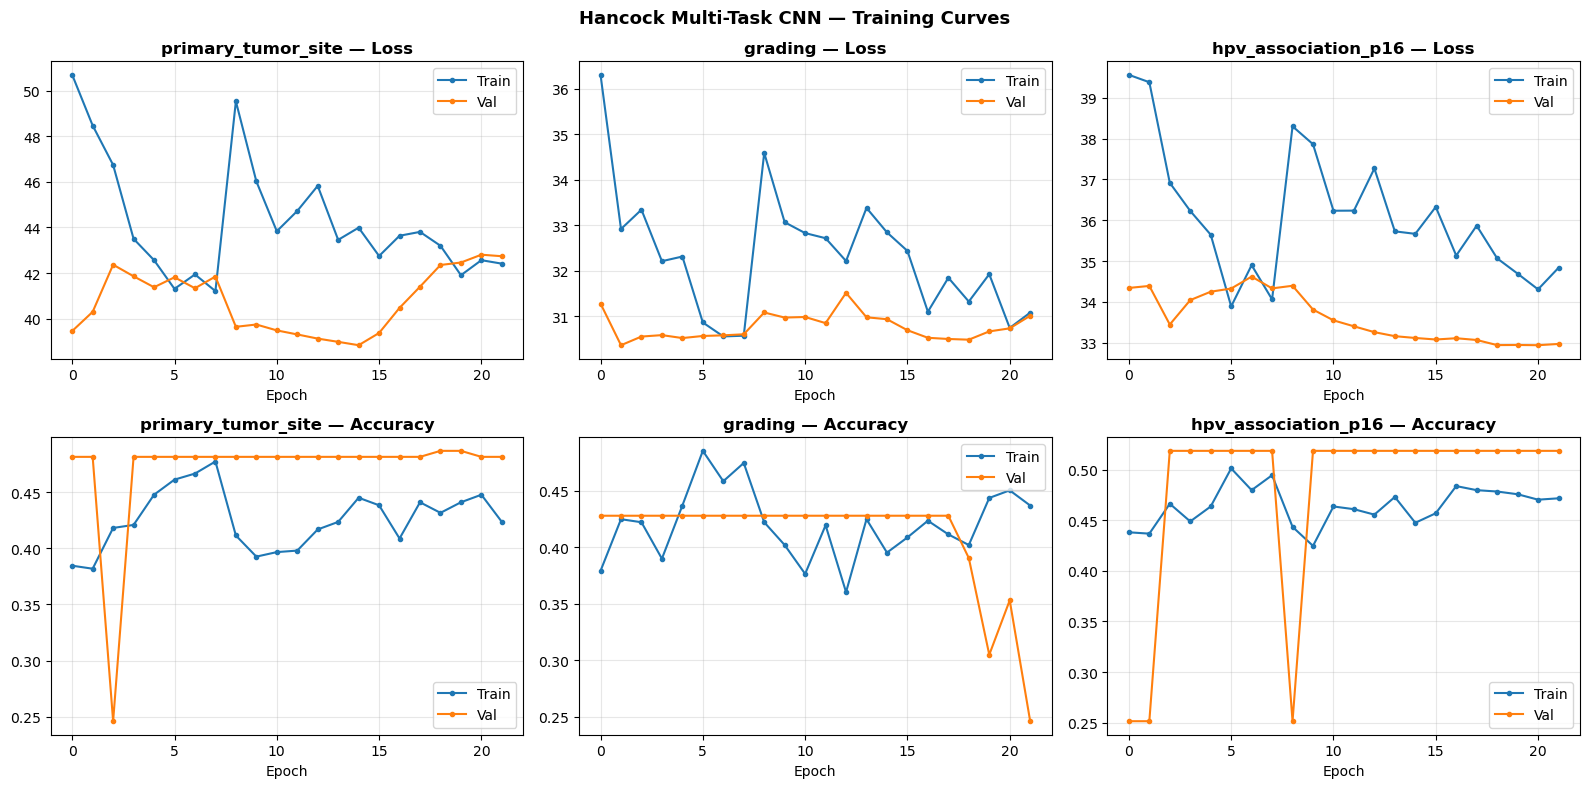

In [12]:
def merge_histories(h1, h2):
    """Concatenate two Keras History objects into a plain dict."""
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history.get(k, [])
    return merged

hist = merge_histories(history1, history2)

heads = [
    ('site_output',  'primary_tumor_site'),
    ('grade_output', 'grading'),
    ('hpv_output',   'hpv_association_p16'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, (head_key, head_name) in enumerate(heads):
    loss_key = f'{head_key}_loss'
    acc_key  = f'{head_key}_accuracy'

    axes[0, col].plot(hist.get(loss_key, []),          label='Train', marker='o', ms=3)
    axes[0, col].plot(hist.get(f'val_{loss_key}', []), label='Val',   marker='o', ms=3)
    axes[0, col].set_title(f'{head_name} — Loss', fontweight='bold')
    axes[0, col].set_xlabel('Epoch'); axes[0, col].legend(); axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(hist.get(acc_key, []),          label='Train', marker='o', ms=3)
    axes[1, col].plot(hist.get(f'val_{acc_key}', []), label='Val',   marker='o', ms=3)
    axes[1, col].set_title(f'{head_name} — Accuracy', fontweight='bold')
    axes[1, col].set_xlabel('Epoch'); axes[1, col].legend(); axes[1, col].grid(alpha=0.3)

plt.suptitle('Hancock Multi-Task CNN — Training Curves', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_curves.png'), dpi=120)
plt.show()

In [13]:
# Collect predictions on the validation set
y_site_true,  y_site_pred  = [], []
y_grade_true, y_grade_pred = [], []
y_hpv_true,   y_hpv_pred   = [], []

for imgs, (s_true, g_true, h_true) in val_ds:
    s_prob, g_prob, h_prob = model.predict(imgs, verbose=0)

    y_site_true.extend(s_true.numpy())
    y_site_pred.extend(np.argmax(s_prob, axis=1))

    g_arr = g_true.numpy()
    valid_g = g_arr >= 0
    y_grade_true.extend(g_arr[valid_g])
    y_grade_pred.extend(np.argmax(g_prob, axis=1)[valid_g])

    h_arr = h_true.numpy()
    valid_h = h_arr >= 0
    y_hpv_true.extend(h_arr[valid_h])
    y_hpv_pred.extend(np.argmax(h_prob, axis=1)[valid_h])


def print_report(name, y_true, y_pred, class_names):
    print('=' * 60)
    print(f'  {name}')
    print('=' * 60)
    print(classification_report(y_true, y_pred, target_names=class_names,
                                 labels=list(range(len(class_names))),
                                 zero_division=0))
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 (wtd) : {f1:.4f}')
    print()


print_report('primary_tumor_site  (val set)',
             y_site_true, y_site_pred, SITE_CLASSES)

print_report('grading  (val set — missing labels excluded)',
             y_grade_true, y_grade_pred, GRADE_CLASSES)

print_report('hpv_association_p16  (val set — missing labels excluded)',
             y_hpv_true, y_hpv_pred, HPV_CLASSES)

  primary_tumor_site  (val set)
              precision    recall  f1-score   support

 Hypopharynx       0.00      0.00      0.00        21
      Larynx       0.00      0.00      0.00        46
 Oral_Cavity       0.00      0.00      0.00        30
  Oropharynx       0.48      1.00      0.65        90

    accuracy                           0.48       187
   macro avg       0.12      0.25      0.16       187
weighted avg       0.23      0.48      0.31       187

  Accuracy : 0.4813
  F1 (wtd) : 0.3127

  grading  (val set — missing labels excluded)
              precision    recall  f1-score   support

          G1       0.00      0.00      0.00         3
          G2       0.00      0.00      0.00        57
          G3       0.57      1.00      0.73        80

    accuracy                           0.57       140
   macro avg       0.19      0.33      0.24       140
weighted avg       0.33      0.57      0.42       140

  Accuracy : 0.5714
  F1 (wtd) : 0.4156

  hpv_association_p16  

In [ ]:
def plot_cm(ax, y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_cm(axes[0], y_site_true,  y_site_pred,  SITE_CLASSES,  'primary_tumor_site')
plot_cm(axes[1], y_grade_true, y_grade_pred, GRADE_CLASSES, 'grading')
plot_cm(axes[2], y_hpv_true,   y_hpv_pred,   HPV_CLASSES,   'hpv_association_p16')

plt.suptitle('Hancock Multi-Task CNN — Confusion Matrices (Val Set)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrices.png'), dpi=120)
plt.show()

In [ ]:
model.save(os.path.join(MODEL_DIR, 'hancock_multitask.keras'))

label_maps = {
    'SITE_CLASSES' : SITE_CLASSES,
    'GRADE_CLASSES': GRADE_CLASSES,
    'HPV_CLASSES'  : HPV_CLASSES,
    'SITE_TO_INT'  : SITE_TO_INT,
    'GRADE_TO_INT' : GRADE_TO_INT,
    'HPV_TO_INT'   : HPV_TO_INT,
}
with open(os.path.join(MODEL_DIR, 'label_maps.json'), 'w') as f:
    json.dump(label_maps, f, indent=2)

print('Saved to', MODEL_DIR)
print('  hancock_multitask.keras')
print('  label_maps.json')

In [ ]:
def predict_patient(patient_id):
    """
    Given a patient_id, load their available slide images and return
    averaged-probability predictions for all three tasks.
    """
    folder = os.path.join(IMAGES_DIR, f'patient_{patient_id}')
    files  = os.listdir(folder)

    candidates = [f for f in files
                  if f.lower().startswith('primarytumor_he')
                  or f.lower().startswith('lymphnode_he')]

    if not candidates:
        print(f'No images found for patient {patient_id}')
        return None

    site_probs, grade_probs, hpv_probs = [], [], []

    for fname in candidates:
        img_path = os.path.join(folder, fname)
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        img = tf.expand_dims(img, 0)

        s_prob, g_prob, h_prob = model.predict(img, verbose=0)
        site_probs.append(s_prob[0])
        grade_probs.append(g_prob[0])
        hpv_probs.append(h_prob[0])

    # Average probabilities across slides then take argmax
    return {
        'primary_tumor_site'  : SITE_CLASSES[np.argmax(np.mean(site_probs,  axis=0))],
        'grading'             : GRADE_CLASSES[np.argmax(np.mean(grade_probs, axis=0))],
        'hpv_association_p16' : HPV_CLASSES[np.argmax(np.mean(hpv_probs,   axis=0))],
    }


# Example (un-comment to test on a specific patient):
# print(predict_patient(102))